# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 04: Transformações dos Dados (Pré-processamento)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA _PRESENCIALMENTE_ COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br), EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                              | Local           |
|-------------------------------|---------------|-----------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Segunda-feira | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quarta-feira  | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font> | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sexta-feira   | <font color='cyan'>13:30</font>   | 1.4 (prédio VI) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_04_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='cyan'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/</font>

O dataset contém informações de sessões de acesso a um site de vendas de uma área de e-commerce que pode ser utilizado para prever o comportamento de clientes ao longo do tempo. Os tipos de dados podem ser subdivididos em 3: dados de navegação (como PageValues), dados temporais (como Month) e dados de usuário (como VisitorType).

## <font color='green'>Preparação</font>

In [20]:
!pip install pandas scikit-learn ucimlrepo

In [21]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=468)

_X_uci = ds.data.features
_y_uci = ds.data.targets

df = pd.concat([_X_uci, _y_uci], axis='columns')
df.head()

print(df.columns) # Utilizado para auxiliar na resposta da pergunta teórica sobre os tipos de dados.

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='cyan'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Isso ocorre porque ao fazer escalonamento no dataset inteiro, pode haver *data* *leakage* (vazamento de dados) - informações do conjunto de teste "vazam" para o cálculo, o que não acontece quando fazemos escalonamento somente nos dados de treinamento (correto).

### <font color='cyan'>Q2: Utilizando a função `train_test_split` biblioteca `scikit-learn`, divida as variáveis independentes (`X`) e a variável alvo (`y`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [22]:
#Usando a função:
from sklearn.model_selection import train_test_split

x = df.drop('Revenue', axis='columns') # Remover y
y = df['Revenue'] # Escolher y

#random_state garante que a divisão aleatória seja sempre a mesma se você rodar o código de novo.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='cyan'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_train`).</font>

In [23]:
cat_col = x_train.select_dtypes(include=['object']).columns
print(cat_col)

Index(['Month', 'VisitorType'], dtype='object')


### <font color='cyan'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras originais.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [24]:
x_train['Month'].sample(10, random_state=42)

,Month
5258,May
8368,Dec
5564,Oct
10481,Nov
4570,May
4815,May
8558,Nov
5247,May
7681,Oct
10353,Dec


### <font color='cyan'>Q5: Aplique a técnica de `One-Hot Encoding` na variável escolhida utilizando a biblioteca scikit-learn.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='cyan'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [25]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
x_train_encoded = encoder.fit_transform(x_train[['Month']])
x_test_encoded = encoder.transform(x_test[['Month']])

### <font color='cyan'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='cyan'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [26]:
df_encoded = pd.DataFrame(x_train_encoded, columns=encoder.get_feature_names_out(), index=x_train.index)
df_encoded.sample(10, random_state=42)

,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
5258,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8368,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5564,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4570,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4815,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8558,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5247,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10353,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Explicação: A coluna 'Month' se subdividiu em outras colunas que representam cada mês como mostrado em: encoder.get_feature_names_out().

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='cyan'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Algoritmos como o kNN funcionam a partir da distância entre pontos; sendo assim, se os dados numéricos não forem escalonados, valores de colunas muito altos terão maior valor relativo que valores de outras colunas menores. Resumindo, sem o escalonamento, o algoritmo é "enganado", pois acaba atribuindo maior importância (pesos maiores) para colunas com números grandes, mesmo que estas sejam menos importantes para explicar o comportamento analisado.

### <font color='cyan'>Q8: Selecione uma coluna numérica contínua de `X_train`. Escreva o nome da característica selecionada abaixo.</font>

In [27]:
num_col = x_train.select_dtypes(include=['number']).columns
print(num_col)

# Para diferenciar variáveis contínuas das discretas (algoritmo da útima atividade):
for col in num_col:
  if x_train[col].nunique() >= 50:
    print(f"{col} é contínua")

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')
Administrative_Duration é contínua
Informational_Duration é contínua
ProductRelated é contínua
ProductRelated_Duration é contínua
BounceRates é contínua
ExitRates é contínua
PageValues é contínua


Minha escolha foi a coluna: PageValues

### <font color='cyan'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [28]:
print(f"Média:          {x_train['PageValues'].mean():.2f}")
print(f"Mediana:        {x_train['PageValues'].median():.2f}")
print(f"Desvio Padrão:  {x_train['PageValues'].std():.2f}")
print(f"Mínimo:         {x_train['PageValues'].min():.2f}")
print(f"Máximo:         {x_train['PageValues'].max():.2f}")

Média:          5.83
Mediana:        0.00
Desvio Padrão:  18.48
Mínimo:         0.00
Máximo:         361.76


### <font color='cyan'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

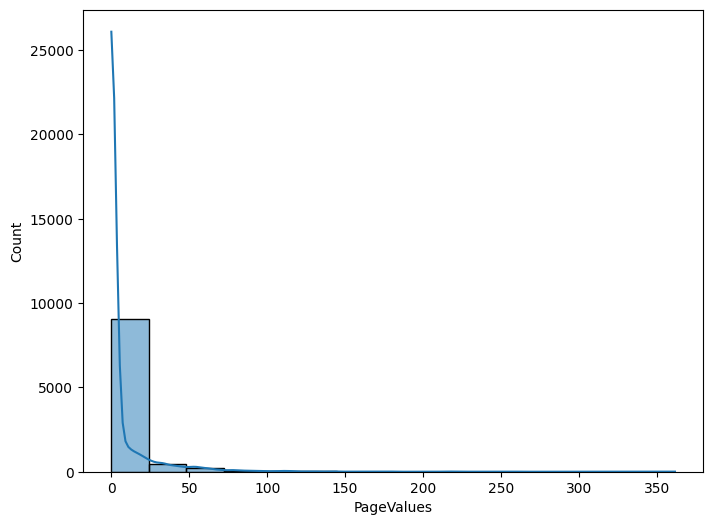

In [29]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.histplot(x_train['PageValues'], kde=True)
plt.show()

### <font color='cyan'>Q11: Aplique o Escalonamento nesta variável. Você pode escolher entre a Padronização (`StandardScaler`) ou a Normalização (`MinMaxScaler`), ambas da biblioteca scikit-learn.</font>

- #### <font color='cyan'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_train` e `X_test`) pelos valores escalonados.</font>
- #### <font color='cyan'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train['PageValues'] = scaler.fit_transform(x_train[['PageValues']])
x_test['PageValues'] = scaler.transform(x_test[['PageValues']])

### <font color='cyan'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [31]:
print(f"Média:          {x_train['PageValues'].mean():.2f}")
print(f"Mediana:        {x_train['PageValues'].median():.2f}")
print(f"Desvio Padrão:  {x_train['PageValues'].std():.2f}")
print(f"Mínimo:         {x_train['PageValues'].min():.2f}")
print(f"Máximo:         {x_train['PageValues'].max():.2f}")

Média:          0.02
Mediana:        0.00
Desvio Padrão:  0.05
Mínimo:         0.00
Máximo:         1.00


### <font color='cyan'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='cyan'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

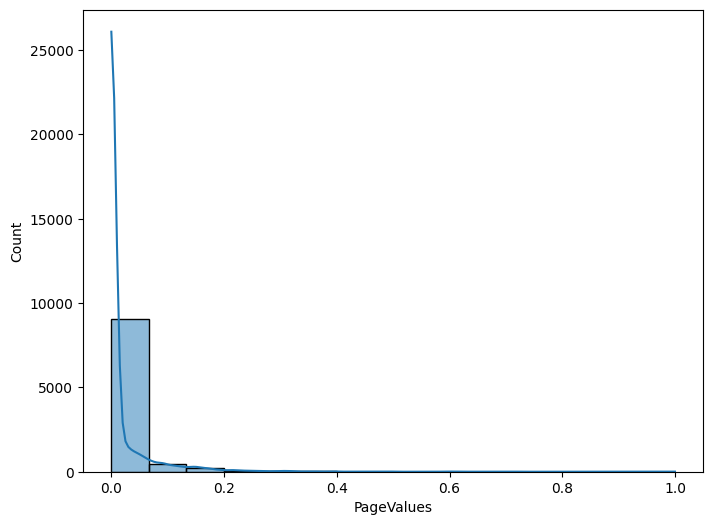

In [32]:
plt.figure(figsize=(8, 6))
sns.histplot(x_train['PageValues'], kde=True)
plt.show()

### <font color='cyan'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='cyan'>O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='cyan'>O que aconteceu com a escala do eixo X e com o formato da curva no gráfico?</font>

Q14.1: Em geral, os dados diminuiram muito de valor. A média diminuiu para 0 e o desvio padrão para 1 - o que já era esperado se tratando de uma padronização;

Q14.2: A escala foi achatada (antes acabava em 350 e agora em 20); o formato da curva permaneceu o mesmo, mas os valores, como aconteceu com as outras estatísticas, tiveram um decréscimo significativo.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='cyan'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='cyan'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [33]:
# Deve ser aplicado separadamente em treino e teste, usando apenas os dados de treino como referência
x_train['Total_Abandon'] = x_train['BounceRates'] + x_train['ExitRates']
x_test['Total_Abandon'] = x_test['BounceRates'] + x_test['ExitRates']

### <font color='cyan'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_train`) e exiba 10 amostras.</font>
- #### <font color='cyan'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [34]:
x_train['Total_Abandon'].sample(10, random_state = 42)

,Total_Abandon
5258,0.150000
8368,0.005882
5564,0.046964
10481,0.019377
4570,0.011111
4815,0.055556
8558,0.110884
5247,0.004000
7681,0.015238
10353,0.120000


### <font color='cyan'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_train`).</font>
- #### <font color='cyan'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='cyan'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='cyan'>Importante: Utilize o `LabelEncoder` da biblioteca `scikit-learn` para transformar a variável alvo (`y_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [35]:
from sklearn.preprocessing import LabelEncoder
lbEncoder = LabelEncoder()
y_train_encoded = lbEncoder.fit_transform(y_train)

comb = pd.DataFrame({
    "Total_Abandon": x_train['Total_Abandon'],
    "Revenue": y_train_encoded
})

pearson_corr = comb['Total_Abandon'].corr(comb['Revenue'])

#y_series = pd.Series(y_train_encoded)
#pearson_corr = x_train['Total_Abandon'].reset_index(drop=True).corr(y_series)
print(f"Correlação de Pearson: {pearson_corr:.4f}")

Correlação de Pearson: -0.1806


Q17.1: A correlação foi negativa e fraca;
Q17.2: Dificilmente ajudará um modelo de ML, uma vez que a correlação é próxima de nula (não há uma relação linear presente), podendo ser até considerada um ruído, dependendo da avaliação.

## <font color='green'>**3.5 Extração / Seleção de Atributos**</font>

### <font color='cyan'>Q18: Qual a principal diferença conceitual entre Extração de Atributos (ex: `Principal Component Analysis`) e Seleção de Atributos (ex: `Variance Threshold`)? Explique.</font>

A Extração de Atributos transforma os originais para criar novos, geralmente reduzindo sua dimensionalidade; enquanto a Seleção de Atributos escolhe um subconjunto dos atributos existentes mais relevantes sem alterá-los.

### <font color='cyan'>Q19: Aplique a técnica de Análise de Componentes Principais (PCA) em todas as variáveis numéricas escalonadas.</font>

- #### <font color='cyan'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis) e ajuste-o aos dados de treinamento.</font>
- #### <font color='cyan'>b) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='cyan'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='cyan'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='cyan'>c) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

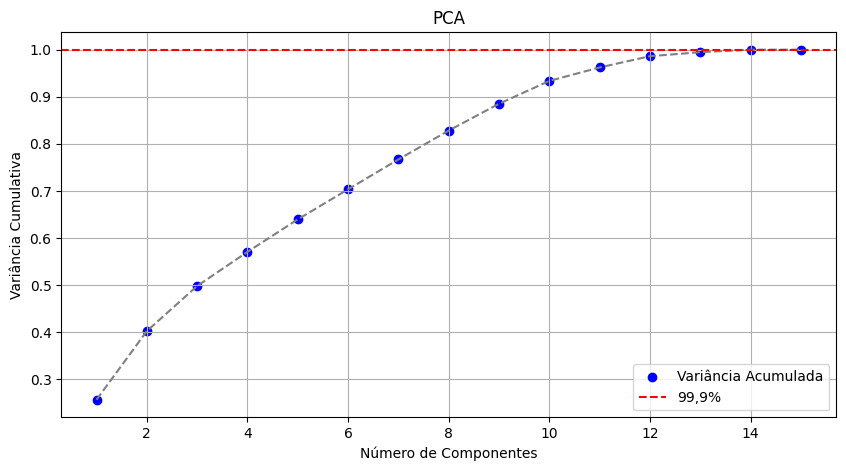

----------------------------------------------------------------------------------------------------------------
Componentes mínimos para 99,9%: 14


In [36]:
#PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# letra a)
x_train_numeric = x_train.select_dtypes(include=[np.number])
x_test_numeric  = x_test.select_dtypes(include=[np.number])

# Padronização é essencial antes de usar o PCA
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_numeric)
x_test_scaled  = scaler.transform(x_test_numeric)

feature_extraction = PCA(n_components=None)
feature_extraction.fit(x_train_scaled)

# letra b)
cumsum = np.cumsum(feature_extraction.explained_variance_ratio_)
x_axis = range(1, len(cumsum) + 1)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, cumsum, color='gray', linestyle='--')
plt.scatter(x_axis, cumsum, c='blue', label='Variância Acumulada')
plt.axhline(y=0.999, color='r', linestyle='--', label='99,9%')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Cumulativa')
plt.title('PCA')
plt.legend()
plt.grid(True)
plt.show()

# letra c)
print("-" * 112)
num_components = np.argmax(cumsum >= 0.999) + 1
print(f"Componentes mínimos para 99,9%: {num_components}")


Justificativa da c)
Diferente outras áreas, no E-commerce, o comportamento de compra é influenciado por detalhes sutis. Um limiar de 99,9% é escolhido para garantir que não descartaremos variáveis que explicam comportamentos de usuários raros, que poderiam ser perdidos.

### <font color='cyan'>Q20: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='cyan'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='cyan'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='cyan'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='cyan'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [37]:
# Letra a)

pcaQ20 = PCA(n_components=num_components)
x_train_pcaQ20 = pcaQ20.fit_transform(x_train_scaled)
x_test_pcaQ20  = pcaQ20.transform(x_test_scaled)

# Letra b)

print("Conjunto de Treinamento:")
print(f"Shape antes da transformação: {x_train_scaled.shape}")
print(f"Shape depois da transformação: {x_train_pcaQ20.shape}")

print("Conjunto de Teste:")
print(f"Shape antes da transformação: {x_test_scaled.shape}")
print(f"Shape depois da transformação: {x_test_pcaQ20.shape}")

# Letra c)
print()
print("As 3 principais colunas que influenciam a principal componente são:")
print((pd.Series(np.abs(pcaQ20.components_[0]), index=x_test_numeric.columns).sort_values(ascending=False)[:3]))

Conjunto de Treinamento:
Shape antes da transformação: (9864, 15)
Shape depois da transformação: (9864, 14)
Conjunto de Teste:
Shape antes da transformação: (2466, 15)
Shape depois da transformação: (2466, 14)

As 3 principais colunas que influenciam a principal componente são:
ExitRates        0.408123
Total_Abandon    0.400430
BounceRates      0.374686
dtype: float64


Após a padronização, a PC1 deixou de ser dominada por variáveis de grande escala e passou a representar um 'Índice de Abandono', sendo influenciada principalmente por ExitRates, Total_Abandon e BounceRates. Isso indica que a maior variação nos dados de navegação está relacionada à rapidez com que os usuários deixam o site.